In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
from pyexcel_ods3 import get_data
import json

In [3]:
def read_ods_as_nested_dict(filename):

    data = get_data(filename)
    sheet_data = data['Sheet1']
    
    # FIXED: Strip spaces from headers
    headers = [header.strip() if isinstance(header, str) else header 
               for header in sheet_data[0][1:]]  # Skip first empty header
    
    result = {}
    current_operation = None
    
    for row in sheet_data[1:]:
        if not row or all(x is None or x == '' for x in row):
            continue
            
        if row[0] is not None and row[0] != '':
            current_operation = row[0]
        
        if current_operation not in result:
            result[current_operation] = {}
        
        # Get vector length and block size
        vector_length = row[1] if len(row) > 1 else None
        block_size = row[2] if len(row) > 2 else None
        
        if vector_length not in result[current_operation]:
            result[current_operation][vector_length] = {}
        
        # Store all metrics for this combination
        metrics = {}
        for i, header in enumerate(headers[2:], 3):  # Skip vector_length and block_size
            if i < len(row):
                # FIXED: Use stripped header as key
                metrics[header] = row[i]
        
        result[current_operation][vector_length][block_size] = metrics
    
    return result

In [4]:
agner_pmc_haswell = read_ods_as_nested_dict('../measurement/agner_measurement_table_haswell_Vec8f.ods')
agner_pmc_skylake = read_ods_as_nested_dict('../measurement/agner_measurement_table_skylake_Vec8f.ods')
agner_pmc_meteorlake = read_ods_as_nested_dict('../measurement/agner_measurement_table_meteorlake_Vec8f.ods')

In [5]:
agner_pmc_haswell.keys()

dict_keys(['permute', 'depermute', 'fir cores', 'part sol', 'homo sol', 'cr forward', 'cr backward', 'iir ph', 'iir cr', 'block filtering', 'scalar', 'filter ph 2', 'filter ph 4', 'filter ph 8', 'filter ph 16', 'filter cr 2', 'filter cr 4', 'filter cr 8', 'filter cr 16', 'filter bf 2', 'filter bf 4', 'filter bf 8', 'filter bf 16', 'filter sc 2', 'filter sc 4', 'filter sc 8', 'filter sc 16'])

In [6]:
agner_pmc_haswell['permute'][8][8]
agner_pmc_haswell['permute'][4][16]

{'data size': 64,
 'cyc': 42,
 'inst': 82,
 'uops': 99,
 'rs': 0,
 'rs std': 0,
 'cm': 0,
 'cm std': 0,
 'cdm': 0,
 'cdm std': 0,
 'cps': 0.65625,
 'ips': 1.28125,
 'ipc': 1.9523809523809523,
 'rss': 0}

In [7]:
f_sc16_pmc_haswell = agner_pmc_haswell['filter sc 16'][8]

f_sc16_cps_haswell = f_sc16_pmc_haswell[1]['cps']
f_sc16_time_haswell = f_sc16_pmc_haswell[1]['real time']

In [8]:
f_bf16_pmc_haswell = agner_pmc_haswell['filter bf 16'][8]

f_bf16_cps_haswell = f_bf16_pmc_haswell[1]['cps']
f_bf16_time_haswell = f_bf16_pmc_haswell[1]['real time']

In [9]:
f_ph16_pmc_haswell = agner_pmc_haswell['filter ph 16'][8]

f_ph16_cps_haswell = np.array([metrics['cps'] for metrics in f_ph16_pmc_haswell.values()])

f_ph16_cps_haswell_first =  f_ph16_cps_haswell[0]

f_ph16_cps_haswell_x = np.argmin(f_ph16_cps_haswell)
f_ph16_cps_haswell = f_ph16_cps_haswell[f_ph16_cps_haswell_x]

f_ph16_time_haswell = np.array([metrics['real time'] for metrics in f_ph16_pmc_haswell.values()])

f_ph16_time_haswell_first =  f_ph16_time_haswell[0]

f_ph16_time_haswell_x = np.argmin(f_ph16_time_haswell)
f_ph16_time_haswell = f_ph16_time_haswell[f_ph16_time_haswell_x]

In [10]:
f_cr16_pmc_haswell = agner_pmc_haswell['filter cr 16'][8]

f_cr16_cps_haswell = np.array([metrics['cps'] for metrics in f_cr16_pmc_haswell.values()])

f_cr16_cps_haswell_first =  f_cr16_cps_haswell[0]

f_cr16_cps_haswell_x = np.argmin(f_cr16_cps_haswell)
f_cr16_cps_haswell = f_cr16_cps_haswell[f_cr16_cps_haswell_x]

f_cr16_time_haswell = np.array([metrics['real time'] for metrics in f_cr16_pmc_haswell.values()])

f_cr16_time_haswell_first =  f_cr16_time_haswell[0]

f_cr16_time_haswell_x = np.argmin(f_cr16_time_haswell)
f_cr16_time_haswell = f_cr16_time_haswell[f_cr16_time_haswell_x]

In [11]:
f_sc16_pmc_skylake = agner_pmc_skylake['filter sc 16'][8]

f_sc16_cps_skylake = f_sc16_pmc_skylake[1]['cps']
f_sc16_time_skylake = f_sc16_pmc_skylake[1]['real time']

In [12]:
f_bf16_pmc_skylake = agner_pmc_skylake['filter bf 16'][8]

f_bf16_cps_skylake = f_bf16_pmc_skylake[1]['cps']
f_bf16_time_skylake = f_bf16_pmc_skylake[1]['real time']

In [13]:
f_ph16_pmc_skylake = agner_pmc_skylake['filter ph 16'][8]

f_ph16_cps_skylake = np.array([metrics['cps'] for metrics in f_ph16_pmc_skylake.values()])

f_ph16_cps_skylake_first =  f_ph16_cps_skylake[0]

f_ph16_cps_skylake_x = np.argmin(f_ph16_cps_skylake)
f_ph16_cps_skylake = f_ph16_cps_skylake[f_ph16_cps_skylake_x]

f_ph16_time_skylake = np.array([metrics['real time'] for metrics in f_ph16_pmc_skylake.values()])

f_ph16_time_skylake_first =  f_ph16_time_skylake[0]

f_ph16_time_skylake_x = np.argmin(f_ph16_time_skylake)
f_ph16_time_skylake = f_ph16_time_skylake[f_ph16_time_skylake_x]

In [14]:
f_cr16_pmc_skylake = agner_pmc_skylake['filter cr 16'][8]

f_cr16_cps_skylake = np.array([metrics['cps'] for metrics in f_cr16_pmc_skylake.values()])

f_cr16_cps_skylake_first =  f_cr16_cps_skylake[0]

f_cr16_cps_skylake_x = np.argmin(f_cr16_cps_skylake)
f_cr16_cps_skylake = f_cr16_cps_skylake[f_cr16_cps_skylake_x]

f_cr16_time_skylake = np.array([metrics['real time'] for metrics in f_cr16_pmc_skylake.values()])

f_cr16_time_skylake_first =  f_cr16_time_skylake[0]

f_cr16_time_skylake_x = np.argmin(f_cr16_time_skylake)
f_cr16_time_skylake = f_cr16_time_skylake[f_cr16_time_skylake_x]

In [15]:
f_sc16_pmc_meteorlake = agner_pmc_meteorlake['filter sc 16'][8]

f_sc16_cps_meteorlake = f_sc16_pmc_meteorlake[1]['cps']
f_sc16_time_meteorlake = f_sc16_pmc_meteorlake[1]['real time']

In [16]:
f_bf16_pmc_meteorlake = agner_pmc_meteorlake['filter bf 16'][8]

f_bf16_cps_meteorlake = f_bf16_pmc_meteorlake[1]['cps']
f_bf16_time_meteorlake = f_bf16_pmc_meteorlake[1]['real time']

In [17]:
f_ph16_pmc_meteorlake = agner_pmc_meteorlake['filter ph 16'][8]

f_ph16_cps_meteorlake = np.array([metrics['cps'] for metrics in f_ph16_pmc_meteorlake.values()])

f_ph16_cps_meteorlake_first =  f_ph16_cps_meteorlake[0]

f_ph16_cps_meteorlake_x = np.argmin(f_ph16_cps_meteorlake)
f_ph16_cps_meteorlake = f_ph16_cps_meteorlake[f_ph16_cps_meteorlake_x]

f_ph16_time_meteorlake = np.array([metrics['real time'] for metrics in f_ph16_pmc_meteorlake.values()])

f_ph16_time_meteorlake_first =  f_ph16_time_meteorlake[0]

f_ph16_time_meteorlake_x = np.argmin(f_ph16_time_meteorlake)
f_ph16_time_meteorlake = f_ph16_time_meteorlake[f_ph16_time_meteorlake_x]

In [18]:
f_cr16_pmc_meteorlake = agner_pmc_meteorlake['filter cr 16'][8]

f_cr16_cps_meteorlake = np.array([metrics['cps'] for metrics in f_cr16_pmc_meteorlake.values()])

f_cr16_cps_meteorlake_first =  f_cr16_cps_meteorlake[0]

f_cr16_cps_meteorlake_x = np.argmin(f_cr16_cps_meteorlake)
f_cr16_cps_meteorlake = f_cr16_cps_meteorlake[f_cr16_cps_meteorlake_x]

f_cr16_time_meteorlake = np.array([metrics['real time'] for metrics in f_cr16_pmc_meteorlake.values()])

f_cr16_time_meteorlake_first =  f_cr16_time_meteorlake[0]

f_cr16_time_meteorlake_x = np.argmin(f_cr16_time_meteorlake)
f_cr16_time_meteorlake = f_cr16_time_meteorlake[f_cr16_time_meteorlake_x]

In [19]:
cps_best_sc = np.array([f_sc16_cps_haswell,f_sc16_cps_skylake,f_sc16_cps_meteorlake])

cps_best_bf = np.array([f_bf16_cps_haswell,f_bf16_cps_skylake,f_bf16_cps_meteorlake])

cps_best_ph = np.array([f_ph16_cps_haswell,f_ph16_cps_skylake,f_ph16_cps_meteorlake])

cps_best_cr = np.array([f_cr16_cps_haswell,f_cr16_cps_skylake,f_cr16_cps_meteorlake])

In [20]:
time_best_sc = np.array([f_sc16_time_haswell,f_sc16_time_skylake,f_sc16_time_meteorlake])

time_best_bf = np.array([f_bf16_time_haswell,f_bf16_time_skylake,f_bf16_time_meteorlake])

time_best_ph = np.array([f_ph16_time_haswell,f_ph16_time_skylake,f_ph16_time_meteorlake])

time_best_cr = np.array([f_cr16_time_haswell,f_cr16_time_skylake,f_cr16_time_meteorlake])

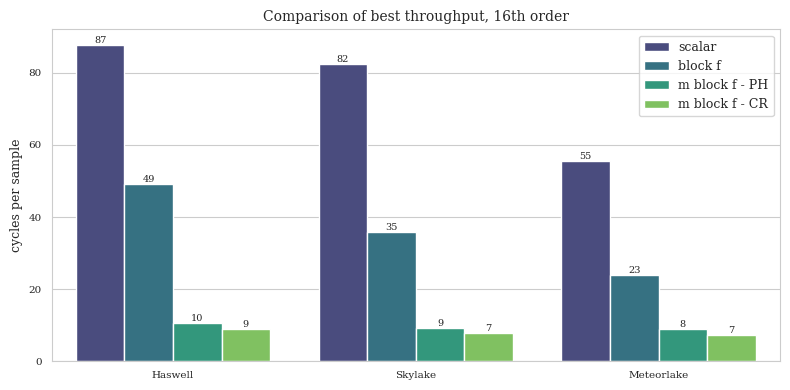

In [21]:
# Set seaborn style and font properties (extracted from your code)
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'legend.fontsize': 9
})

# Create sample data - three numpy arrays with the same length
array1 = cps_best_sc
array2 = cps_best_bf
array3 = cps_best_ph
array4 = cps_best_cr

# Create x-axis labels
x_labels = ['Haswell', 'Skylake', 'Meteorlake']

# Method 1: Using seaborn with melted DataFrame (Recommended)
# print("Method 1: Grouped Bar Plot using Seaborn - Enhanced Styling")

# Create a DataFrame from the numpy arrays
df = pd.DataFrame({
    'Categories': x_labels,
    'scalar': array1,
    'block f': array2,
    'm block f - PH': array3,
    'm block f - CR': array4
})

# Melt the DataFrame to long format (required for seaborn)
df_melted = df.melt(id_vars='Categories', 
                    value_vars=['scalar', 'block f', 'm block f - PH', 'm block f - CR'],
                    var_name='Array', 
                    value_name='Values')

# Create the grouped bar plot with professional styling
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_melted, x='Categories', y='Values', hue='Array', 
           palette='viridis', ax=ax)

# Customize the plot with styling from your code
ax.set_xlabel('')
ax.set_ylabel('cycles per sample')
ax.set_title('Comparison of best throughput, 16th order')

# Enhanced legend styling (from your code)
legend = ax.legend(title='', framealpha=0.9)
legend.get_frame().set_alpha(0.8)

# Rotate x-axis labels for better readability
# plt.xticks(rotation=45)

# Add value labels on top of bars (optional)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=7)

plt.tight_layout()
plt.show()



In [22]:
cps_fast_sc = np.array([f_sc16_cps_haswell,f_sc16_cps_skylake,f_sc16_cps_meteorlake])

cps_fast_bf = np.array([f_bf16_cps_haswell,f_bf16_cps_skylake,f_bf16_cps_meteorlake])

cps_fast_ph = np.array([f_ph16_cps_haswell_first,f_ph16_cps_skylake_first,f_ph16_cps_meteorlake_first])

cps_fast_cr = np.array([f_cr16_cps_haswell_first,f_cr16_cps_skylake_first,f_cr16_cps_meteorlake_first])

In [23]:
time_fast_sc = np.array([f_sc16_time_haswell,f_sc16_time_skylake,f_sc16_time_meteorlake])

time_fast_bf = np.array([f_bf16_time_haswell,f_bf16_time_skylake,f_bf16_time_meteorlake])

time_fast_ph = np.array([f_ph16_time_haswell_first,f_ph16_time_skylake_first,f_ph16_time_meteorlake_first])

time_fast_cr = np.array([f_cr16_time_haswell_first,f_cr16_time_skylake_first,f_cr16_time_meteorlake_first])

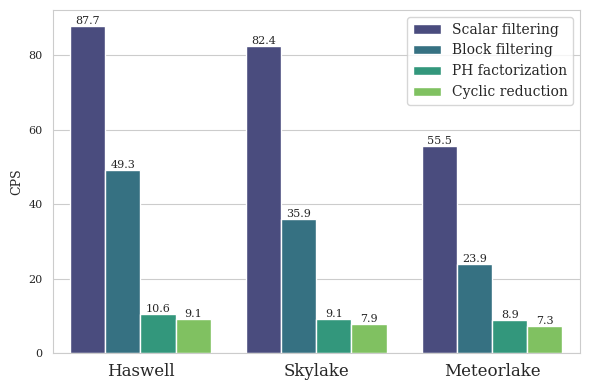

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set seaborn style and font properties (extracted from your code)
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 12,
    'ytick.labelsize': 8,
    'legend.fontsize': 10
})

# Create sample data - three numpy arrays with the same length
array1 = cps_fast_sc
array2 = cps_fast_bf
# array3 = cps_fast_ph
# array4 = cps_fast_cr

# array1 = cps_best_sc
# array2 = cps_best_bf
array3 = cps_best_ph
array4 = cps_best_cr

# Create x-axis labels
x_labels = ['Haswell', 'Skylake', 'Meteorlake']

# Method 1: Using seaborn with melted DataFrame (Recommended)
# print("Method 1: Grouped Bar Plot using Seaborn - Enhanced Styling")

# Create a DataFrame from the numpy arrays
df = pd.DataFrame({
    'Categories': x_labels,
    'Scalar filtering': array1,
    'Block filtering': array2,
    'PH factorization': array3,
    'Cyclic reduction': array4
})

# Melt the DataFrame to long format (required for seaborn)
df_melted = df.melt(id_vars='Categories', 
                    value_vars=['Scalar filtering', 'Block filtering', 'PH factorization', 'Cyclic reduction'],
                    var_name='Array', 
                    value_name='Values')

# Create the grouped bar plot with professional styling
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df_melted, x='Categories', y='Values', hue='Array', 
           palette='viridis', ax=ax)

# Customize the plot with styling from your code
ax.set_xlabel('')
ax.set_ylabel('CPS')
# ax.set_title('Comparison of shortest latency, 16th order')

# Enhanced legend styling (from your code)
legend = ax.legend(title='', framealpha=0.9)
legend.get_frame().set_alpha(0.8)

# 🔹 Make legend labels bold
# for text in legend.get_texts():
#     text.set_fontweight('bold')

# Rotate x-axis labels for better readability
# plt.xticks(rotation=45)

# Add value labels on top of bars (optional)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)

plt.tight_layout()

# plt.savefig('plot42.png', bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none')
plt.show()

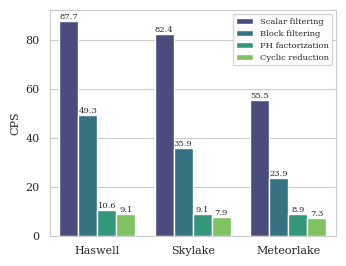

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sns.set_style("whitegrid")
# plt.rcParams.update({
#     'font.family': 'serif',
#     'font.size': 6,
#     'axes.titlesize': 7,
#     'axes.labelsize': 7,
#     'xtick.labelsize': 6,
#     'ytick.labelsize': 6,
#     'legend.fontsize': 5
# })
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 6
})

array1 = cps_fast_sc
array2 = cps_fast_bf
array3 = cps_best_ph
array4 = cps_best_cr

x_labels = ['Haswell', 'Skylake', 'Meteorlake']

df = pd.DataFrame({
    'Categories': x_labels,
    'Scalar filtering': array1,
    'Block filtering': array2,
    'PH factorization': array3,
    'Cyclic reduction': array4
})

df_melted = df.melt(id_vars='Categories',
                    value_vars=['Scalar filtering', 'Block filtering', 'PH factorization', 'Cyclic reduction'],
                    var_name='Array',
                    value_name='Values')

fig, ax = plt.subplots(figsize=(3.5, 2.7))

sns.barplot(data=df_melted, x='Categories', y='Values', hue='Array',
            palette='viridis', ax=ax)

ax.set_xlabel('')
ax.set_ylabel('CPS')

legend = ax.legend(title='', framealpha=0.9)
legend.get_frame().set_alpha(0.8)

for container in ax.containers:
    # ax.bar_label(container, fmt='%.1f', fontsize=4.5)
    ax.bar_label(container, fmt='%.1f', fontsize=6)

plt.tight_layout()
plt.savefig('../plot/plot42.png', bbox_inches='tight', dpi=600, facecolor='white', edgecolor='none')
plt.show()